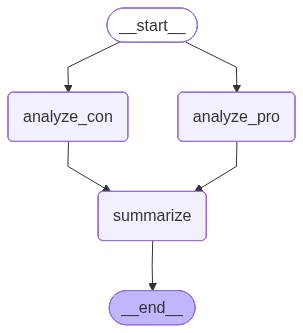


--- Running MapReduce Graph ---
--- Analyzing Cons ---
--- Analyzing Pros ---
--- Summarizing Analyses ---

--- Final Summary ---
Deploying large language models (LLMs) in production environments presents numerous challenges but also offers significant benefits. 

**Cons** include their resource intensiveness and high costs related to hardware, energy, and infrastructure. LLMs can suffer from latency issues, impacting real-time application performance, and scalability remains a complex issue due to their size and infrastructure needs. Operational costs, including cloud services and licensing, can be substantial. Ethical concerns such as bias, data privacy, and security pose risks, especially as these models may reflect biases or expose sensitive information. LLMs often function as "black boxes," lacking interpretability and transparency crucial for accountable sectors like healthcare. Maintenance demands and dependence on specific architectures further complicate their deployment. Mor

In [2]:
import os
from dotenv import load_dotenv
from typing import TypedDict, List, Annotated
import operator

# Core LangGraph components
from langgraph.graph import StateGraph, START, END

# LLM and messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

# For displaying the graph image
from IPython.display import Image, display
import nest_asyncio

# Apply patch for running async in Jupyter if needed (though this graph is synchronous)
nest_asyncio.apply()

# Load API keys and set up tracing
load_dotenv()
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_PROJECT"] = "Intro to LangGraph"

# --- Define the State ---
class GraphState(TypedDict):
    topic: str
    analysis_results: Annotated[List[str], operator.add] # Accumulate results here

# --- Define Nodes ---
# "Map" nodes: Analyze topic from different perspectives
def analyze_pro(state: GraphState):
    print("--- Analyzing Pros ---")
    llm = ChatOpenAI(model="gpt-4o")
    prompt = f"What are the main pros of {state['topic']}?"
    response = llm.invoke([SystemMessage(content="You are a helpful analyst."), HumanMessage(content=prompt)])
    # Append result to the list in the state
    return {"analysis_results": [f"Pros: {response.content}"]}

def analyze_con(state: GraphState):
    print("--- Analyzing Cons ---")
    llm = ChatOpenAI(model="gpt-4o")
    prompt = f"What are the main cons of {state['topic']}?"
    response = llm.invoke([SystemMessage(content="You are a helpful analyst."), HumanMessage(content=prompt)])
    # Append result to the list in the state
    return {"analysis_results": [f"Cons: {response.content}"]}

# "Reduce" node: Combine the analyses
def summarize_analyses(state: GraphState):
    print("--- Summarizing Analyses ---")
    llm = ChatOpenAI(model="gpt-4o")
    
    combined_results = "\n".join(state['analysis_results'])
    prompt = f"Summarize the following analyses:\n\n{combined_results}"
    response = llm.invoke([SystemMessage(content="You are a summarizer."), HumanMessage(content=prompt)])
    
    # Just print the summary for this example
    print("\n--- Final Summary ---")
    print(response.content)
    # Return an empty dict as we don't need to update the state further
    return {}

# --- Build the Graph ---
workflow = StateGraph(GraphState)

# Add the map nodes
workflow.add_node("analyze_pro", analyze_pro)
workflow.add_node("analyze_con", analyze_con)

# Add the reduce node
workflow.add_node("summarize", summarize_analyses)

# Start node triggers both analyses concurrently
workflow.add_edge(START, "analyze_pro")
workflow.add_edge(START, "analyze_con")

# Both analyses must finish before summarizing
workflow.add_edge("analyze_pro", "summarize")
workflow.add_edge("analyze_con", "summarize")

# Summarize is the final step
workflow.add_edge("summarize", END)

# Compile the graph
app = workflow.compile()

# --- Display the Graph Image ---
# Generate and display a PNG image of the graph's structure
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not draw graph: {e}. Ensure pygraphviz and Pillow are installed.")

# --- Run the Graph ---
print("\n--- Running MapReduce Graph ---")
inputs = {"topic": "using large language models in production"}
final_state = app.invoke(inputs)

print("\n--- Graph Finished ---")